In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.db'):
            print(os.path.join(root, f))


/content/drive/MyDrive/DOCUMENTS PERSO/ECOLE/EPSI TOULOUSE - M1/CERTIFICATION/MSPR TPRE813/Database/mspr.db


In [ ]:
import sqlite3
import pandas as pd

In [ ]:
DB_PATH = '/content/drive/MyDrive/EPSI TOULOUSE - M1/CERTIFICATION/MSPR TPRE813/Database/mspr.db'
conn = sqlite3.connect(DB_PATH)

# Vérification
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
display(tables)

,name
0,departement
1,chomage
2,demographie
3,criminalite
4,election
5,entreprises


Charger les tables

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

chomage  = pd.read_sql("SELECT * FROM chomage", conn)
demo     = pd.read_sql("SELECT * FROM demographie", conn)
crim     = pd.read_sql("SELECT * FROM criminalite", conn)
election = pd.read_sql("SELECT * FROM election", conn)
ent      = pd.read_sql("SELECT * FROM entreprises", conn)


In [ ]:
# Criminalité : taux moyen toutes catégories par dept
crim_agg = crim.groupby("code_dept")["taux_pour_mille"].mean().reset_index()
crim_agg.columns = ["code_dept", "taux_crim_moyen"]

# Chômage : dernière année disponible par dept
chomage_last = (chomage.sort_values("annee")
                .groupby("code_dept").last()
                .reset_index()[["code_dept", "taux_chomage_moyen"]])

# Election : score Le Pen et Macron par dept
elec_pivot = (election[election["nom"].isin(["LE PEN", "MACRON"])]
              .pivot(index="code_dept", columns="nom", values="pct_voix_exp")
              .reset_index())
elec_pivot.columns.name = None

# Démographie : pop totale dernière année
demo_last = (demo.sort_values("annee")
             .groupby("code_dept").last()
             .reset_index()[["code_dept", "pop_totale"]])

# Fusion
df = (elec_pivot
      .merge(chomage_last, on="code_dept")
      .merge(crim_agg, on="code_dept")
      .merge(demo_last, on="code_dept"))

display(df.head())


,code_dept,LE PEN,MACRON,taux_chomage_moyen,taux_crim_moyen,pop_totale
0,01,26.05,27.69,5.68,2.269945,678981
1,02,39.27,22.08,10.35,2.609586,539099
2,03,27.06,26.73,7.98,2.235267,343485
3,04,26.90,21.51,8.00,2.658292,170650
4,05,22.84,23.78,6.38,2.435364,145357


Cellule — matrice de corrélation

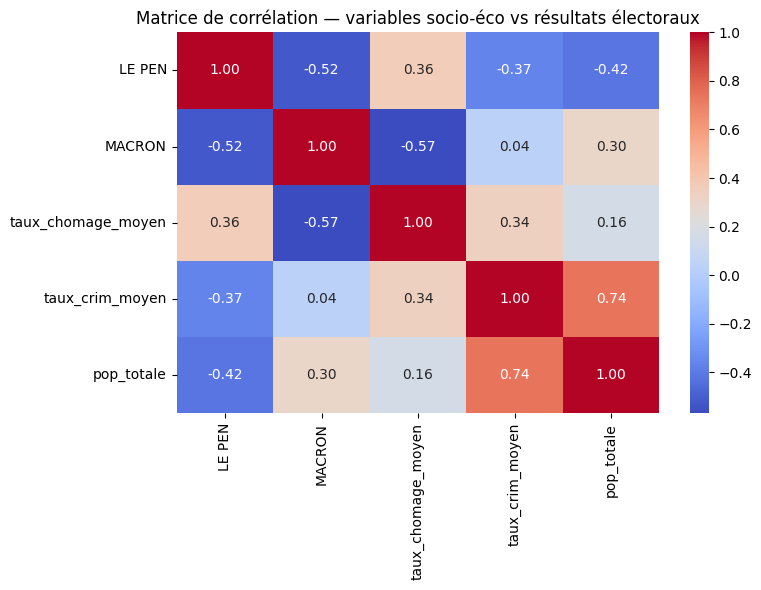

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns="code_dept").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation — variables socio-éco vs résultats électoraux")
plt.tight_layout()
plt.show()

Ce que dit la matrice de corrélation :

Observation	Valeur


*   Chômage élevé → plus de votes Le Pen +0.36
*   Chômage élevé → moins de votes Macron	-0.57
*   Départements peuplés → moins Le Pen	-0.42
*   Départements peuplés → plus Macron	+0.30
*   Le Pen et Macron s'opposent fortement	-0.52



Cellule — histogrammes

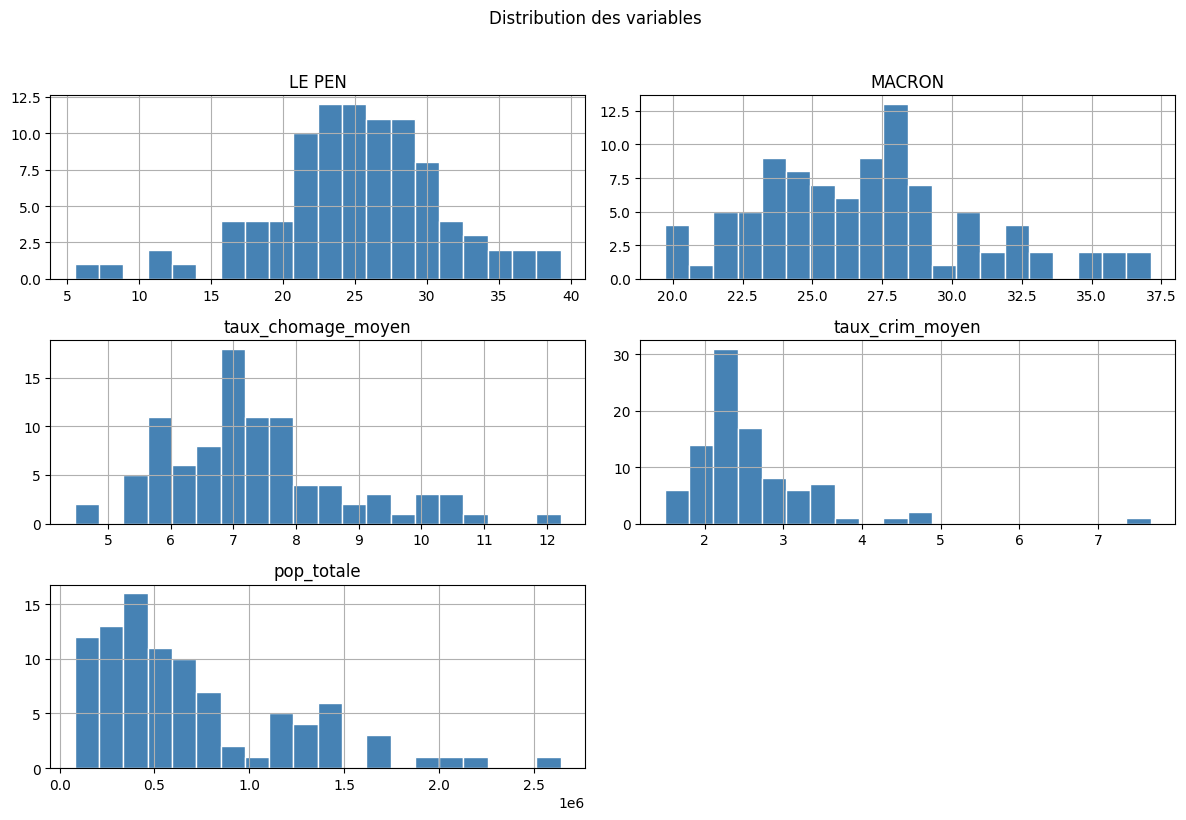

In [ ]:
df.drop(columns="code_dept").hist(figsize=(12, 8), bins=20, color="steelblue", edgecolor="white")
plt.suptitle("Distribution des variables", y=1.02)
plt.tight_layout()
plt.show()

Cellule — évolution du chômage dans le temps

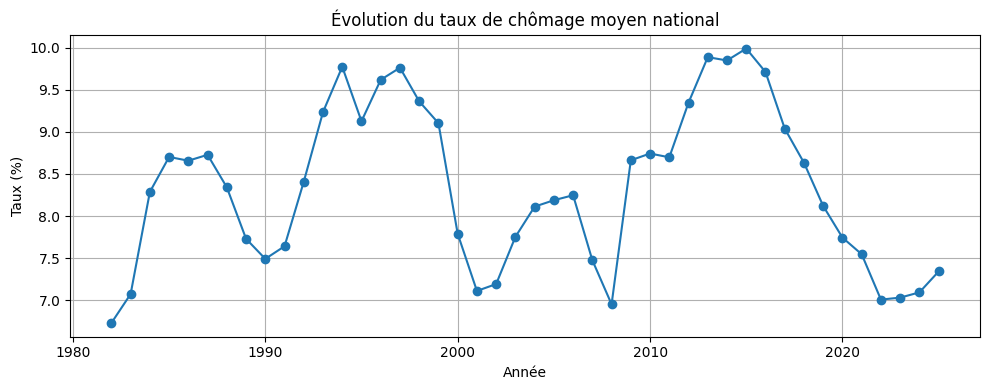

In [ ]:
chomage_nat = chomage.groupby("annee")["taux_chomage_moyen"].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(chomage_nat["annee"], chomage_nat["taux_chomage_moyen"], marker="o")
plt.title("Évolution du taux de chômage moyen national")
plt.xlabel("Année")
plt.ylabel("Taux (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

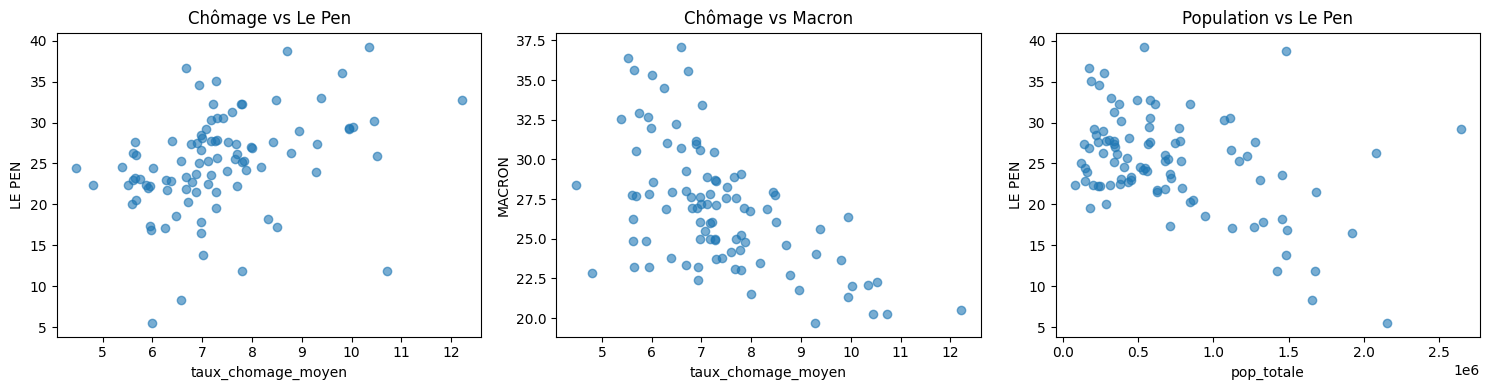

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ("taux_chomage_moyen", "LE PEN",  "Chômage vs Le Pen"),
    ("taux_chomage_moyen", "MACRON",  "Chômage vs Macron"),
    ("pop_totale",         "LE PEN",  "Population vs Le Pen"),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

plt.tight_layout()
plt.show()

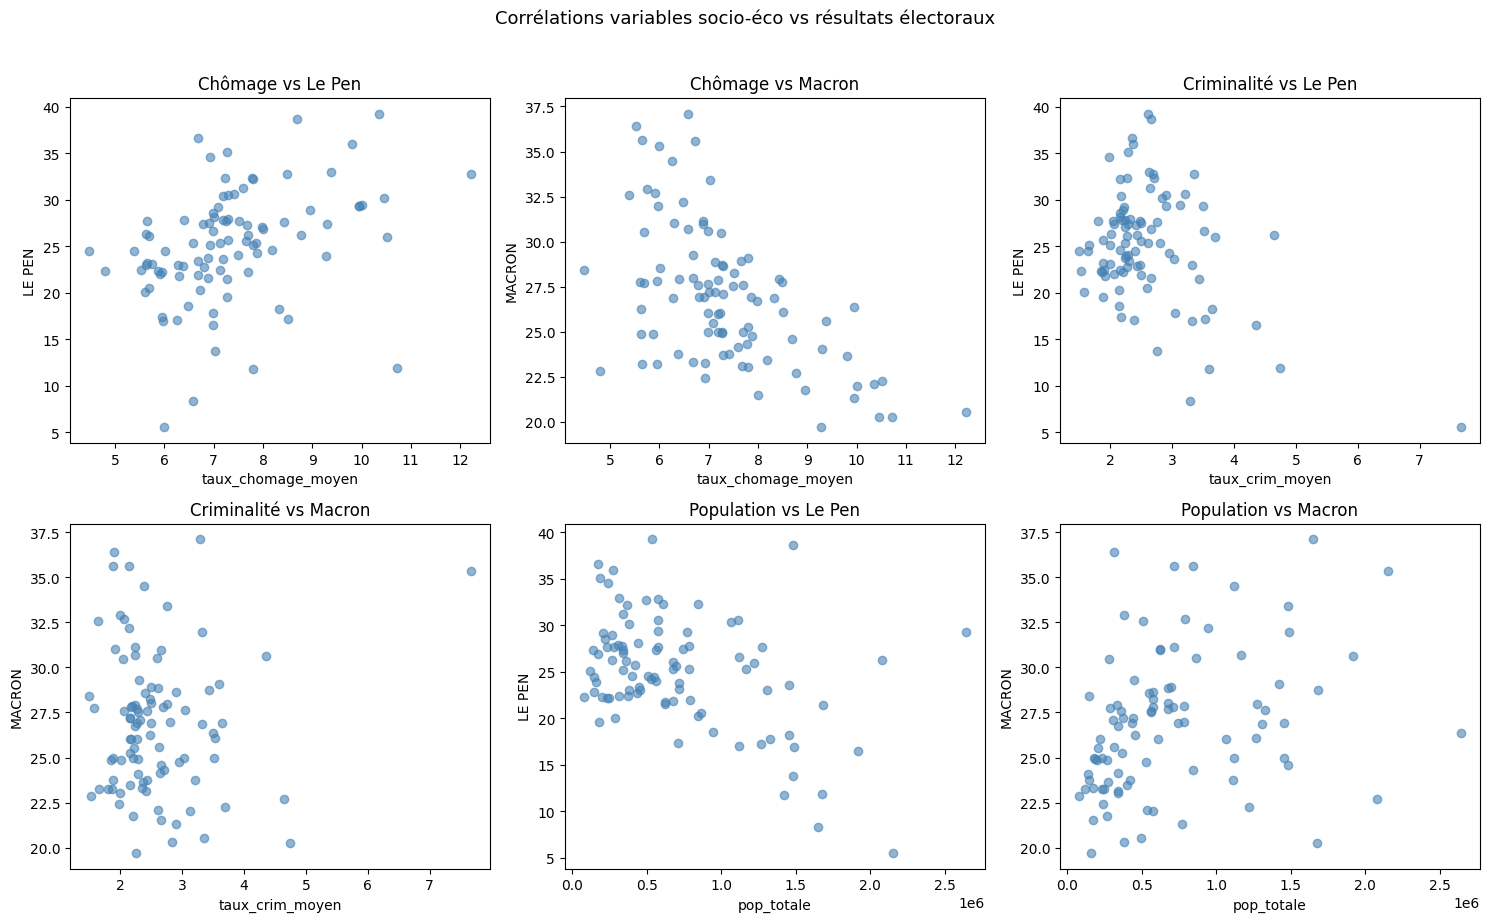

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

pairs = [
    ("taux_chomage_moyen", "LE PEN",       "Chômage vs Le Pen"),
    ("taux_chomage_moyen", "MACRON",       "Chômage vs Macron"),
    ("taux_crim_moyen",    "LE PEN",       "Criminalité vs Le Pen"),
    ("taux_crim_moyen",    "MACRON",       "Criminalité vs Macron"),
    ("pop_totale",         "LE PEN",       "Population vs Le Pen"),
    ("pop_totale",         "MACRON",       "Population vs Macron"),
]

for ax, (x, y, title) in zip(axes.flat, pairs):
    ax.scatter(df[x], df[y], alpha=0.6, color="steelblue")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

plt.suptitle("Corrélations variables socio-éco vs résultats électoraux", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()